In [1]:
!pip install -q openai pandas

In [2]:
import os
import pandas as pd
from openai import OpenAI

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from google.colab import userdata

API_KEY = userdata.get("Gen")

client = OpenAI(
    api_key=API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

print("OpenRouter client created successfully!")

OpenRouter client created successfully!


In [7]:
response = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {
            "role": "user",
            "content": "Say only: SCHOOL SECURITY AI SUCCESS"
        }
    ],
    max_tokens=100
)

print(response.choices[0].message.content)

SCHOOL SECURITY AI SUCCESS


In [8]:
import pandas as pd

security_data = pd.DataFrame({
    "Incident_ID": [1, 2, 3, 4],
    "Incident": [
        "Student forgot ID card",
        "Unknown visitor entered school campus",
        "Fire alarm activated in laboratory",
        "Student found wandering in restricted area"
    ],
    "Location": [
        "Main Gate",
        "Main Gate",
        "Science Laboratory",
        "Computer Laboratory"
    ],
    "Status": [
        "Resolved",
        "Under Investigation",
        "Resolved",
        "Under Investigation"
    ]
})

security_data

,Incident_ID,Incident,Location,Status
0,1,Student forgot ID card,Main Gate,Resolved
1,2,Unknown visitor entered school campus,Main Gate,Under Investigation
2,3,Fire alarm activated in laboratory,Science Laboratory,Resolved
3,4,Student found wandering in restricted area,Computer Laboratory,Under Investigation


In [9]:
def analyze_incident(incident):

    prompt = f"""
You are a School Security AI Assistant.

Analyze the following school security incident:

Incident:
{incident}

Give the answer in this format:

Category:
Severity:
Summary:
Recommended Action:

Severity must be one of:
LOW, MEDIUM, HIGH, CRITICAL
"""

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=300
    )

    return response.choices[0].message.content

In [10]:
incident = "An unknown person entered the school campus without permission."

result = analyze_incident(incident)

print(result)

**Category:** Unauthorized Campus Access  
**Severity:** HIGH  
**Summary:** An unknown individual gained entry onto the school campus without any form of permission or identification. The incursion poses a potential risk to students, staff, and property, and could be indicative of a security breach or intent to cause harm.  
**Recommended Action:**  
1. **Immediate Notification** – Alert school security personnel and campus police immediately.  
2. **Emergency Lockdown** – Initiate a controlled lockdown of all non‑essential areas, ensuring all faculty and students are safely secured.  
3. **Safe Evacuation** – Evacuate


In [11]:
incident = "A student forgot to bring their school ID card."

result = analyze_incident(incident)

print(result)

Category: Access Control  
Severity: LOW  
Summary: A student failed to bring their school ID card, potentially limiting their access to restricted areas and creating a minor security lapse.  
Recommended Action:  
1. Verify the student’s identity through alternative means (e.g., photo ID, parent contact, or staff verification).  
2. Grant temporary access to necessary areas while ensuring no sensitive resources are exposed.  
3. Remind the student to bring their ID card to school the next day and provide a checklist for required items.  
4. Review the ID issuance and reminder process to reduce future occurrences.


In [12]:
def security_assistant(question):

    prompt = f"""
You are an AI Security Assistant for a school.

Help the school security administrator with the following question:

{question}

Give a simple, practical and professional answer.
Do not make final decisions on behalf of school authorities.
If there is an emergency, recommend contacting the appropriate
school authorities or emergency services.

Answer:
"""

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=300
    )

    return response.choices[0].message.content

In [13]:
question = "What should security staff do if an unauthorized visitor is detected?"

answer = security_assistant(question)

print(answer)

**If an unauthorized visitor is detected, security staff should:**

1. **Confirm the situation**  
   * Quickly assess whether the person is truly unauthorized (e.g., no visitor badge, no appointment, no staff escort).  
   * Keep a safe distance and remain calm.

2. **Notify the appropriate authority**  
   * Call the school security supervisor or the designated on‑call officer immediately.  
   * Provide a concise description: location, appearance, behavior, and any suspicious items.

3. **Maintain a safe perimeter**  
   * If possible, gently guide the visitor toward a public area or a staff‑only zone while keeping a safe distance.  
   * Do not confront or physically restrain the individual unless it is absolutely necessary for safety.

4. **Document the incident**  
   * Record the time, location, visitor’s description, and any actions taken.  
   * Note any relevant observations (e.g., suspicious behavior, items carried).

5. **Follow the school’s visitor‑management protocol**  


In [14]:
question = "What should we do if a fire alarm is activated in the school?"

answer = security_assistant(question)

print(answer)

**What to Do if a Fire Alarm is Activated in the School**

1. **Stay Calm and Listen**  
   - Footage of the bell or PA message might confirm whether it’s a drill or a real emergency.  
   - If you hear a device call or “Emergency, do not return to classes” announcement, treat it as a real situation.

2. **Evacuate Immediately**  
   - Walk to the nearest exit. Do not run with bags or personal items.  
   - Follow your school's designated evacuation route (e.g., the main hallway, stairwell, or walkway to the assembly point).  
   - Do not use elevators during a fire alarm.

3. **Assist Others if You Can**  
   - Help children, staff, or peers who need assistance—especially those with disabilities or special needs.  
   - Keep a clear path to the exit and avoid blocking doors or stairways.

4. **Proceed to the Assembly Point**  
   - Move to the predetermined safe area outside the building (often


In [15]:
visitor_data = pd.DataFrame({
    "Visitor_ID": [101, 102, 103],
    "Name": [
        "Rahul Sharma",
        "Priya Patil",
        "Amit Joshi"
    ],
    "Purpose": [
        "Meeting Principal",
        "Parent Meeting",
        "Maintenance Work"
    ],
    "Entry_Time": [
        "09:30 AM",
        "10:15 AM",
        "11:00 AM"
    ],
    "Status": [
        "Checked Out",
        "Inside Campus",
        "Inside Campus"
    ]
})

visitor_data

,Visitor_ID,Name,Purpose,Entry_Time,Status
0,101,Rahul Sharma,Meeting Principal,09:30 AM,Checked Out
1,102,Priya Patil,Parent Meeting,10:15 AM,Inside Campus
2,103,Amit Joshi,Maintenance Work,11:00 AM,Inside Campus


In [16]:
def visitor_summary(name, purpose, entry_time, status):

    prompt = f"""
You are a School Security Administration AI.

Create a short visitor security summary.

Visitor Name: {name}
Purpose: {purpose}
Entry Time: {entry_time}
Current Status: {status}

Give the output in this format:

Visitor:
Purpose:
Entry Time:
Status:
Security Note:
"""

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=200
    )

    return response.choices[0].message.content

In [17]:
result = visitor_summary(
    "Rahul Sharma",
    "Meeting Principal",
    "09:30 AM",
    "Checked Out"
)

print(result)

Visitor: Rahul Sharma  
Purpose: Meeting Principal  
Entry Time: 09:30 AM  
Status: Checked Out  
Security Note: Visitor completed meeting and checkout procedures. All logs confirmed.


In [18]:
def generate_security_report(data):

    incident_text = ""

    for _, row in data.iterrows():
        incident_text += f"""
Incident ID: {row['Incident_ID']}
Incident: {row['Incident']}
Location: {row['Location']}
Status: {row['Status']}

"""

    prompt = f"""
You are a School Security Administration AI.

Prepare a professional daily security report
using the following incident records:

{incident_text}

Include:

1. Total number of incidents
2. Important incidents
3. Overall security situation
4. Recommended actions

Keep the report simple and professional.
"""

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=500
    )

    return response.choices[0].message.content

In [19]:
report = generate_security_report(security_data)

print(report)

**School Security Administration – Daily Incident Report**  
**Date:** 11 September 2026  
**Prepared by:** School Security Administration AI  

| Incident ID | Incident Description | Location | Status |
|-------------|----------------------|----------|--------|
| 1 | Student forgot ID card | Main Gate | Resolved |
| 2 | Unknown visitor entered school campus | Main Gate | Under Investigation |
| 3 | Fire alarm activated in laboratory | Science Laboratory | Resolved |
| 4 | Student found wandering in restricted area | Computer Laboratory | Under Investigation |

---

### 1. Total Number of Incidents  
**4 incidents** were recorded during the reporting period.

### 2. Important Incidents  
| Incident ID | Description | Why it’s Important |
|-------------|-------------|--------------------|
| 2 | Unknown visitor entered school campus | Potential security breach; requires verification of visitor credentials. |
| 4 | Student found wandering in restricted area | Indicates possible lapse in s

In [20]:
total_incidents = len(security_data)

resolved_incidents = len(
    security_data[security_data["Status"] == "Resolved"]
)

investigation_incidents = len(
    security_data[security_data["Status"] == "Under Investigation"]
)

print("===================================")
print(" SCHOOL SECURITY DASHBOARD")
print("===================================")
print("Total Incidents:", total_incidents)
print("Resolved Incidents:", resolved_incidents)
print("Under Investigation:", investigation_incidents)
print("===================================")

 SCHOOL SECURITY DASHBOARD
Total Incidents: 4
Resolved Incidents: 2
Under Investigation: 2


In [21]:
security_data["Severity"] = [
    "LOW",
    "HIGH",
    "CRITICAL",
    "MEDIUM"
]

security_data

,Incident_ID,Incident,Location,Status,Severity
0,1,Student forgot ID card,Main Gate,Resolved,LOW
1,2,Unknown visitor entered school campus,Main Gate,Under Investigation,HIGH
2,3,Fire alarm activated in laboratory,Science Laboratory,Resolved,CRITICAL
3,4,Student found wandering in restricted area,Computer Laboratory,Under Investigation,MEDIUM


In [22]:
low = len(security_data[security_data["Severity"] == "LOW"])
medium = len(security_data[security_data["Severity"] == "MEDIUM"])
high = len(security_data[security_data["Severity"] == "HIGH"])
critical = len(security_data[security_data["Severity"] == "CRITICAL"])

print("===================================")
print(" SECURITY RISK SUMMARY")
print("===================================")
print("LOW:", low)
print("MEDIUM:", medium)
print("HIGH:", high)
print("CRITICAL:", critical)
print("===================================")

 SECURITY RISK SUMMARY
LOW: 1
MEDIUM: 1
HIGH: 1
CRITICAL: 1


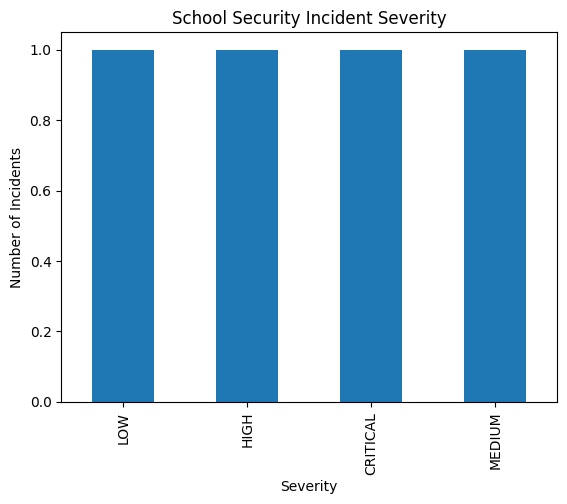

In [23]:
import matplotlib.pyplot as plt

severity_counts = security_data["Severity"].value_counts()

severity_counts.plot(kind="bar")

plt.title("School Security Incident Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Incidents")
plt.show()

In [24]:
def school_security_system():

    while True:

        print("\n========================================")
        print(" SCHOOL SECURITY ADMINISTRATION SYSTEM")
        print("========================================")
        print("1. Analyze Security Incident")
        print("2. Ask Security Assistant")
        print("3. Visitor Summary")
        print("4. Generate Security Report")
        print("5. View Security Dashboard")
        print("6. Exit")
        print("========================================")

        choice = input("Enter your choice: ")

        # OPTION 1
        if choice == "1":

            incident = input("\nEnter security incident: ")

            result = analyze_incident(incident)

            print("\n----------- AI INCIDENT ANALYSIS -----------")
            print(result)
            print("--------------------------------------------")


        # OPTION 2
        elif choice == "2":

            question = input("\nEnter your security question: ")

            answer = security_assistant(question)

            print("\n----------- AI SECURITY ASSISTANT -----------")
            print(answer)
            print("---------------------------------------------")


        # OPTION 3
        elif choice == "3":

            name = input("\nVisitor Name: ")
            purpose = input("Purpose of Visit: ")
            entry_time = input("Entry Time: ")
            status = input("Visitor Status: ")

            result = visitor_summary(
                name,
                purpose,
                entry_time,
                status
            )

            print("\n------------- VISITOR SUMMARY --------------")
            print(result)
            print("---------------------------------------------")


        # OPTION 4
        elif choice == "4":

            report = generate_security_report(security_data)

            print("\n----------- DAILY SECURITY REPORT -----------")
            print(report)
            print("---------------------------------------------")


        # OPTION 5
        elif choice == "5":

            total = len(security_data)

            resolved = len(
                security_data[
                    security_data["Status"] == "Resolved"
                ]
            )

            investigation = len(
                security_data[
                    security_data["Status"] == "Under Investigation"
                ]
            )

            high = len(
                security_data[
                    security_data["Severity"] == "HIGH"
                ]
            )

            critical = len(
                security_data[
                    security_data["Severity"] == "CRITICAL"
                ]
            )

            print("\n========================================")
            print("       SCHOOL SECURITY DASHBOARD")
            print("========================================")
            print("Total Incidents:", total)
            print("Resolved Incidents:", resolved)
            print("Under Investigation:", investigation)
            print("High Risk Incidents:", high)
            print("Critical Incidents:", critical)
            print("========================================")


        # OPTION 6
        elif choice == "6":

            print("\nThank you for using School Security AI.")
            print("System closed.")
            break


        else:

            print("\nInvalid choice!")
            print("Please enter a number from 1 to 6.")

In [ ]:
school_security_system()


 SCHOOL SECURITY ADMINISTRATION SYSTEM
1. Analyze Security Incident
2. Ask Security Assistant
3. Visitor Summary
4. Generate Security Report
5. View Security Dashboard
6. Exit
Enter your choice: 1

Enter security incident: Unknown person entered the computer laboratory without permission.

----------- AI INCIDENT ANALYSIS -----------
Category: Unauthorized Physical Access  
Severity: MEDIUM  
Summary: An unidentified individual gained entry to the computer laboratory without proper authorization. No immediate evidence of theft or damage, but the breach indicates a lapse in perimeter security and poses a risk of potential equipment tampering or data compromise.  
Recommended Action:  
1. Review surveillance footage to identify the intruder and assess their movements.  
2. Conduct an immediate inventory check of all computers, peripherals, and stored data.  
3. Secure the laboratory by reinforcing access controls (e.g., badge system, keypad locks).  
4. Notify campus security and the IT